# 03 · Speech, listening, language areas & reading

Frontal-midline theta marks cognitive effort.  We compare the interview vs rest, split it into
**listening vs answering** (muscle-based, no microphone), probe **Broca/Wernicke homologues** via
left/right alpha asymmetry, and contrast **reading aloud vs dialogue**.

In [1]:
import warnings, pathlib, sys
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

# Make the committed `analysis` package importable whether this notebook is
# launched from the repo root or from the notebooks/ folder.
_c = pathlib.Path.cwd()
REPO = next(p for p in [_c] + list(_c.parents) if (p / "analysis").is_dir())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
from analysis import dataset, eegkit as K

# Point DATA_DIR at any folder of EDFs named <subject><E|C><id>[_pN].edf
#   None -> repo data/  |  a path -> that folder  |  or set env EEG_DATA_DIR
DATA_DIR = None
recs = dataset.discover(DATA_DIR)

# Neutral per-recording labels (exp1, exp2, ctrl1, ctrl2) so participant codes
# never leak into figure titles / filenames.
_gi, LABEL = {}, {}
for _r in recs:
    _g = _r["group"]; _gi[_g] = _gi.get(_g, 0) + 1
    LABEL[_r["key"]] = ("exp" if _g == "E" else "ctrl") + str(_gi[_g])
def lbl(r): return LABEL[r["key"]]

FIG = REPO / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
IAF_DEF = 9.7

def ec_window(r):
    st = K.get_stages(K.load(r["path"]), r["key"])
    return [s for s in st if s[0].startswith("rest_close")][0]

def get_iaf(r):
    raw = K.load(r["path"]); ec = ec_window(r)
    _, live = K.get(raw, ec[1], ec[2])
    return K.iaf(raw, live, ec[1], ec[2])

def stage_of(r, nm):
    st = K.get_stages(K.load(r["path"]), r["key"])
    return [s for s in st if s[0] == nm]

print(f"discovered {len(recs)} recordings ->", {lbl(r): r["group"] for r in recs})
print("figures ->", str(FIG))


discovered 4 recordings -> {'exp1': 'E', 'exp2': 'E', 'ctrl1': 'C', 'ctrl2': 'C'}
figures -> /home/eugen/coding/ms-thesis/eeg-analysis/reports/figures


## 1. Interview (speech) vs the preceding eyes-open rest

In [2]:
def base_rest(r, t):
    st = K.get_stages(K.load(r["path"]), r["key"])
    pre = [s for s in st if s[0].startswith("rest_open") and s[2] <= t]
    return pre[-1] if pre else (st[0] if st else None)
rows = []
for r in recs:
    sp = stage_of(r, "speech")
    if not sp: continue
    sp = sp[0]; raw = K.load(r["path"]); fs = raw.info["sfreq"]; IAF = get_iaf(r)
    base = base_rest(r, sp[1])
    if not base: continue
    xB, lB = K.get(raw, base[1], base[2]); xS, lS = K.get(raw, sp[1], sp[2])
    c = "Fz" if "Fz" in lS else "FCz"
    cB = "Fz" if "Fz" in lB else "FCz"
    thS = K.band_pow(xS[lS.index(c)], fs, 4, 8).mean()
    thB = K.band_pow(xB[lB.index(cB)], fs, 4, 8).mean()
    oi = [lS.index(k) for k in K.OCCIP if k in lS]
    oiB = [lB.index(k) for k in K.OCCIP if k in lB]
    alS = K.band_pow(xS[oi], fs, IAF - 2, IAF + 2).mean()
    alB = K.band_pow(xB[oiB], fs, IAF - 2, IAF + 2).mean() if oiB else np.nan
    pct = lambda a, b: 100 * (a / b - 1)
    rows.append(dict(recording=lbl(r), group=r["group"], fmtheta_vs_rest=pct(thS, thB),
                     alpha_vs_rest=pct(alS, alB)))
print(pd.DataFrame(rows).round(0).to_string(index=False))
print("\nfmTheta rises during the interview in the experimental subject (both sessions), not in control.")


recording group  fmtheta_vs_rest  alpha_vs_rest
     exp1     E            112.0           33.0
     exp2     E             56.0          -29.0
    ctrl1     C             -4.0           83.0
    ctrl2     C              0.0            0.0

fmTheta rises during the interview in the experimental subject (both sessions), not in control.


## 2. Listening vs answering inside the interview

In [3]:
def seg_metrics(r):
    sp = stage_of(r, "speech")
    if not sp: return None
    sp = sp[0]; raw = K.load(r["path"]); fs = raw.info["sfreq"]; IAF = get_iaf(r)
    tw, z, cls = K.speak_listen_mask(raw, sp[1], sp[2])
    x, live = K.get(raw, sp[1], sp[2])
    c = "Fz" if "Fz" in live else "FCz"; oi = [live.index(k) for k in K.OCCIP if k in live]
    fp = "Fp1" if "Fp1" in live else "Fp2"
    W, S = int(K.WIN_S * fs), int(1 * fs)
    def win(mask, fn):
        w = np.where(mask)[0]
        if len(w) < 2: return np.nan, 0
        a0, a1 = int(w[0] * S), int(w[-1] * S) + W
        return fn(x[:, a0:a1]), w.sum() * S / fs
    def thf(xw): return K.band_pow(xw[[live.index(c)]], fs, 4, 8).mean()
    def alf(xw): return K.band_pow(xw[oi], fs, IAF - 2, IAF + 2).mean()
    def brf(xw): return K.blink_rate(xw[live.index(fp)], fs)
    thL, nL = win(cls == -1, thf); thS, nS = win(cls == 1, thf)
    alL, _ = win(cls == -1, alf); alS, _ = win(cls == 1, alf)
    brL, _ = win(cls == -1, brf); brS, _ = win(cls == 1, brf)
    base = base_rest(r, sp[1])
    if base:
        xB, lB = K.get(raw, base[1], base[2])
        cB = "Fz" if "Fz" in lB else "FCz"
        thB = K.band_pow(xB[lB.index(cB)], fs, 4, 8).mean()
    else:
        thB = np.nan
    pct = lambda a, b: 100 * (a / b - 1)
    return dict(recording=lbl(r), group=r["group"], listen_vs_rest_th=pct(thL, thB),
                answer_vs_listen_th=pct(thS, thL), alpha_answer_vs_listen=pct(alS, alL),
                blinks_listen=brL, blinks_answer=brS)
seg_rows = [m for m in (seg_metrics(r) for r in recs) if m]
print(pd.DataFrame(seg_rows).round(0).to_string(index=False))
print("\nIn the stuttering subject theta is ALREADY high while just listening -> engagement state, not "
      "articulatory effort.  Control shows a speak-specific theta bump.")


recording group  listen_vs_rest_th  answer_vs_listen_th  alpha_answer_vs_listen  blinks_listen  blinks_answer
     exp1     E               97.0                 34.0                     8.0           58.0           63.0
     exp2     E               58.0                  1.0                    -1.0           61.0           64.0
    ctrl1     C              -10.0                 24.0                    89.0           16.0           25.0
    ctrl2     C                0.0                  7.0                   -16.0           33.0           33.0

In the stuttering subject theta is ALREADY high while just listening -> engagement state, not articulatory effort.  Control shows a speak-specific theta bump.


### Listening / speaking segmentation (visual sanity check)

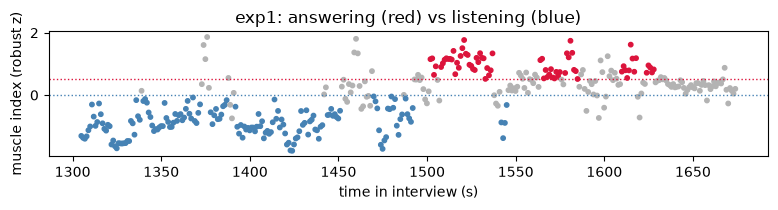

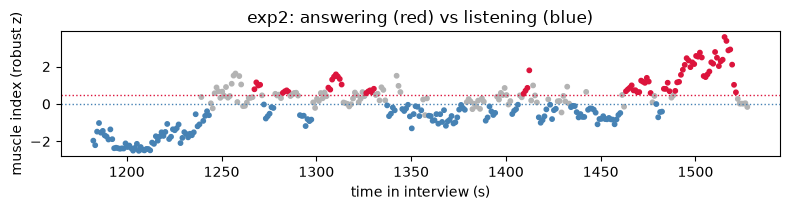

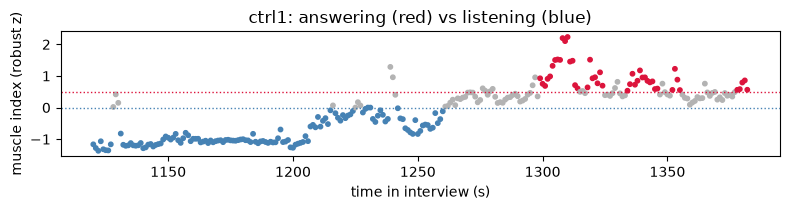

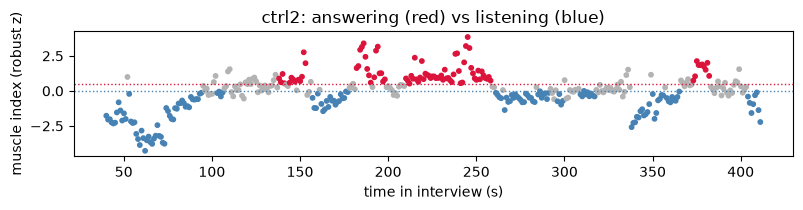

In [4]:
for r in recs:
    sp = stage_of(r, "speech")
    if not sp: continue
    raw = K.load(r["path"])
    tw, z, cls = K.speak_listen_mask(raw, sp[0][1], sp[0][2])
    col = np.where(cls == 1, "crimson", np.where(cls == -1, "steelblue", "0.7"))
    fig, ax = plt.subplots(figsize=(8, 2.2))
    ax.scatter(tw, z, c=col, s=10)
    ax.axhline(0.5, color="crimson", ls=":", lw=1); ax.axhline(0.0, color="steelblue", ls=":", lw=1)
    ax.set_xlabel("time in interview (s)"); ax.set_ylabel("muscle index (robust z)")
    ax.set_title(f"{lbl(r)}: answering (red) vs listening (blue)")
    fig.tight_layout(); fig.savefig(FIG / f"speak_listen_{lbl(r)}.png", dpi=100)
    plt.show(); plt.close(fig)


## 3. Broca / Wernicke homologues (10-20 proxies)
Only **within-state** left/right alpha asymmetry is trustworthy — during the interview *all* bands
inflate (sweat lowers impedance), so %-changes against rest are not interpretable.

In [5]:
PAIRS = [("Broca_L", "Broca_R"), ("Wern_L", "Wern_R")]
def asym(r, Lk, Rk, mask=None):
    raw = K.load(r["path"]); fs = raw.info["sfreq"]; IAF = get_iaf(r)
    sp = stage_of(r, "speech")
    x, live = K.get(raw, sp[0][1], sp[0][2])
    L, R = K.REGIONS[Lk], K.REGIONS[Rk]
    il = [live.index(c) for c in L if c in live]; ir = [live.index(c) for c in R if c in live]
    if not il or not ir: return np.nan
    if mask is None:
        a0, a1 = 0, x.shape[1]
    else:
        W, S = int(K.WIN_S * fs), int(1 * fs); w = np.where(mask)[0]
        if len(w) < 2: return np.nan
        a0, a1 = int(w[0] * S), int(w[-1] * S) + W
    pl = K.band_pow(x[il][:, a0:a1], fs, IAF - 2, IAF + 2).mean()
    pr = K.band_pow(x[ir][:, a0:a1], fs, IAF - 2, IAF + 2).mean()
    return 100 * (pl - pr) / (pl + pr + 1e-12)
rows = []
for r in recs:
    sp = stage_of(r, "speech")
    if not sp: continue
    raw = K.load(r["path"])
    _, _, cls = K.speak_listen_mask(raw, sp[0][1], sp[0][2])
    row = dict(recording=lbl(r), group=r["group"])
    for lk, rk in PAIRS:
        row[f"{lk} vs {rk} (answer)"] = asym(r, lk, rk, cls == 1)
        row[f"{lk} vs {rk} (listen)"] = asym(r, lk, rk, cls == -1)
    rows.append(row)
print(pd.DataFrame(rows).round(0).to_string(index=False))
print("\nStuttering subject: left Broca relatively idle (+), right-dominant Wernicke (-) on both days;")
print("control balanced/left-leaning.  Positive = more LEFT alpha = LESS left activation.")


recording group  Broca_L vs Broca_R (answer)  Broca_L vs Broca_R (listen)  Wern_L vs Wern_R (answer)  Wern_L vs Wern_R (listen)
     exp1     E                         23.0                         19.0                      -18.0                      -17.0
     exp2     E                          9.0                          8.0                      -16.0                      -14.0
    ctrl1     C                          2.0                          2.0                       19.0                        1.0
    ctrl2     C                          3.0                          2.0                        6.0                        9.0

Stuttering subject: left Broca relatively idle (+), right-dominant Wernicke (-) on both days;
control balanced/left-leaning.  Positive = more LEFT alpha = LESS left activation.


## 4. Reading aloud vs dialogue (same effort, different disfluency)

In [6]:
def read_vs_speak(r):
    rd = stage_of(r, "reading"); sp = stage_of(r, "speech")
    if not rd or not sp: return None
    raw = K.load(r["path"]); fs = raw.info["sfreq"]
    xS, liveS = K.get(raw, *sp[0][1:]); xR, liveR = K.get(raw, *rd[0][1:])
    both = [c for c in liveR if c in liveS]
    if not both: return None
    c = "Fz" if "Fz" in both else "FCz"
    iS, iR = liveS.index(c), liveR.index(c)
    thR = K.band_pow(xR[[iR]], fs, 4, 8).mean(); thS = K.band_pow(xS[[iS]], fs, 4, 8).mean()
    _, _, cls = K.speak_listen_mask(raw, *sp[0][1:])
    W, S = int(K.WIN_S * fs), int(1 * fs); w = np.where(cls == 1)[0]
    if len(w) < 2: return None
    a0, a1 = int(w[0] * S), int(w[-1] * S) + W
    thS_v = K.band_pow(xS[[iS]][:, a0:a1], fs, 4, 8).mean()
    fp = "Fp1" if "Fp1" in both else "Fp2"
    blR = K.blink_rate(xR[liveR.index(fp)], fs)
    blS = K.blink_rate(xS[liveS.index(fp)][a0:a1], fs)
    pct = lambda a, b: 100 * (a / b - 1)
    return dict(recording=lbl(r), group=r["group"], theta_read=round(thR, 1),
                theta_speakwin=round(thS_v, 1), speak_vs_read=pct(thS_v, thR),
                blinks_read=round(blR), blinks_speak=round(blS))
rs = [m for m in (read_vs_speak(r) for r in recs) if m]
print(pd.DataFrame(rs).to_string(index=False))
print("\nSame effort signature in both vocal tasks for the stuttering subject, although disfluency "
      "differed -> the theta marker tracks vocalizing, NOT stuttering events.")


recording group  theta_read  theta_speakwin  speak_vs_read  blinks_read  blinks_speak
     exp1     E        14.1            16.2      14.926228           46            63
     exp2     E        11.2            11.7       4.607234           46            64
    ctrl1     C         4.1             4.5       8.958552           16            25

Same effort signature in both vocal tasks for the stuttering subject, although disfluency differed -> the theta marker tracks vocalizing, NOT stuttering events.
